In [56]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from skimage import data, img_as_float
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops_table
from skimage.morphology import remove_small_objects

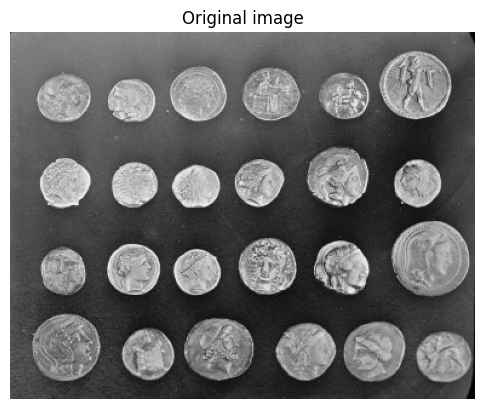

In [57]:
image = img_as_float(data.coins())

plt.figure(figsize=(6, 5))
plt.imshow(image, cmap="gray")
plt.title("Original image")
plt.axis("off")
plt.show()

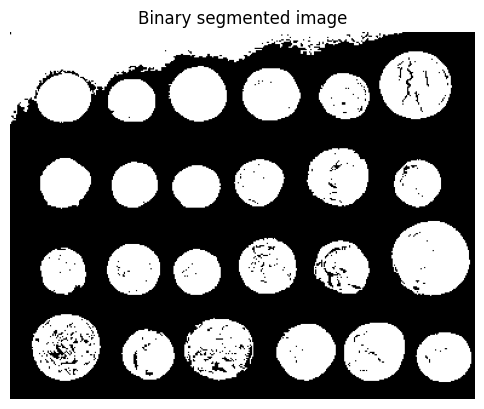

Threshold value: 0.4172564338235294


In [58]:
threshold = threshold_otsu(image)

binary = image > threshold
binary_clean = remove_small_objects(binary, min_size=25)

plt.figure(figsize=(6, 5))
plt.imshow(binary_clean, cmap="gray")
plt.title("Binary segmented image")
plt.axis("off")
plt.show()

print("Threshold value:", threshold)

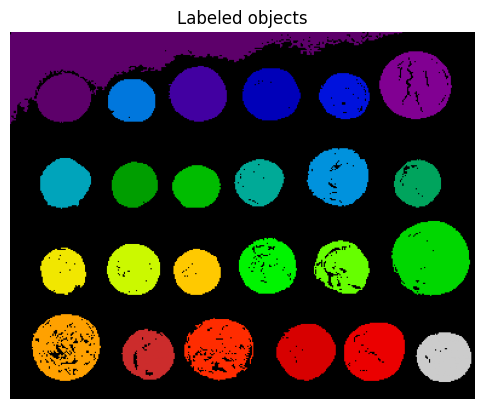

Number of objects: 24


In [59]:
labeled_image = label(binary_clean)

plt.figure(figsize=(6, 5))
plt.imshow(labeled_image, cmap="nipy_spectral")
plt.title("Labeled objects")
plt.axis("off")
plt.show()

print("Number of objects:", labeled_image.max())

In [60]:
props = regionprops_table(
    labeled_image,
    properties=(
        "label",
        "area",
        "eccentricity",
        "extent",
        "axis_major_length"
    )
)

df = pd.DataFrame(props)

df

,label,area,eccentricity,extent,axis_major_length
0,1,9147.0,0.978666,0.371467,308.859109
1,2,2468.0,0.327227,0.734524,59.915775
2,3,1687.0,0.295960,0.764040,47.447950
3,4,1635.0,0.387259,0.792151,47.643154
4,5,1200.0,0.394199,0.751880,41.376386
5,6,1135.0,0.424994,0.831502,40.004383
6,7,1838.0,0.371171,0.750817,51.382466
7,8,1327.0,0.341573,0.752268,42.482464
8,9,1204.0,0.377598,0.735043,40.927289
9,10,1134.0,0.331198,0.726923,39.702096


In [61]:
df_sorted = df.sort_values(by="area", ascending=False)

df_sorted

,label,area,eccentricity,extent,axis_major_length
0,1,9147.0,0.978666,0.371467,308.859109
12,13,3063.0,0.304491,0.760050,64.272476
1,2,2468.0,0.327227,0.734524,59.915775
18,19,2124.0,0.236196,0.677512,58.173669
19,20,1983.0,0.422713,0.669028,56.042516
20,21,1925.0,0.426914,0.802083,52.824971
6,7,1838.0,0.371171,0.750817,51.382466
21,22,1730.0,0.332465,0.751194,48.524399
2,3,1687.0,0.295960,0.764040,47.447950
13,14,1642.0,0.302749,0.743659,48.418434


In [62]:
df_sorted.head(10)

,label,area,eccentricity,extent,axis_major_length
0,1,9147.0,0.978666,0.371467,308.859109
12,13,3063.0,0.304491,0.760050,64.272476
1,2,2468.0,0.327227,0.734524,59.915775
18,19,2124.0,0.236196,0.677512,58.173669
19,20,1983.0,0.422713,0.669028,56.042516
20,21,1925.0,0.426914,0.802083,52.824971
6,7,1838.0,0.371171,0.750817,51.382466
21,22,1730.0,0.332465,0.751194,48.524399
2,3,1687.0,0.295960,0.764040,47.447950
13,14,1642.0,0.302749,0.743659,48.418434


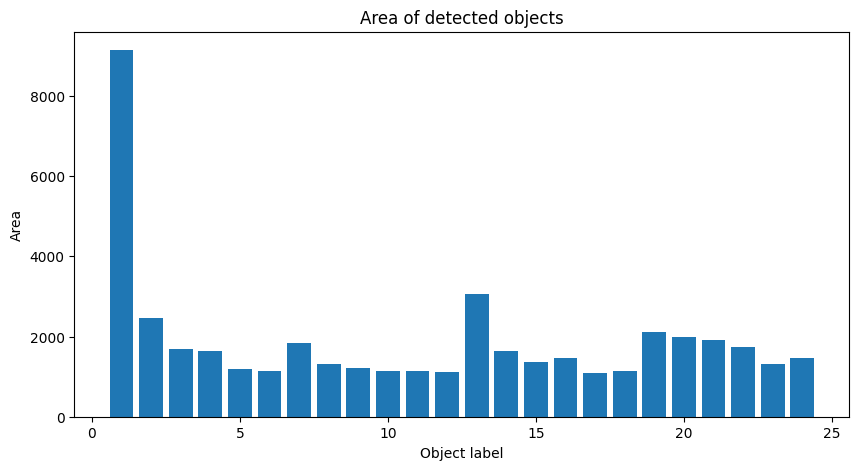

In [63]:
plt.figure(figsize=(10, 5))
plt.bar(df["label"], df["area"])
plt.xlabel("Object label")
plt.ylabel("Area")
plt.title("Area of detected objects")
plt.show()

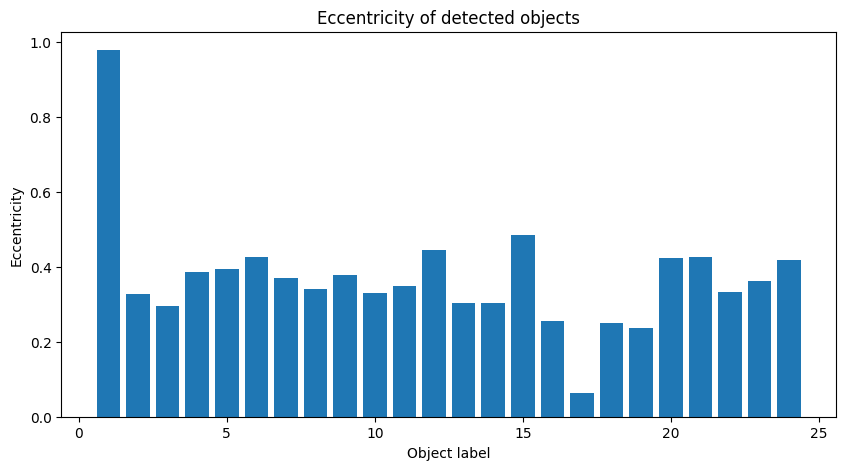

In [64]:
plt.figure(figsize=(10, 5))
plt.bar(df["label"], df["eccentricity"])
plt.xlabel("Object label")
plt.ylabel("Eccentricity")
plt.title("Eccentricity of detected objects")
plt.show()

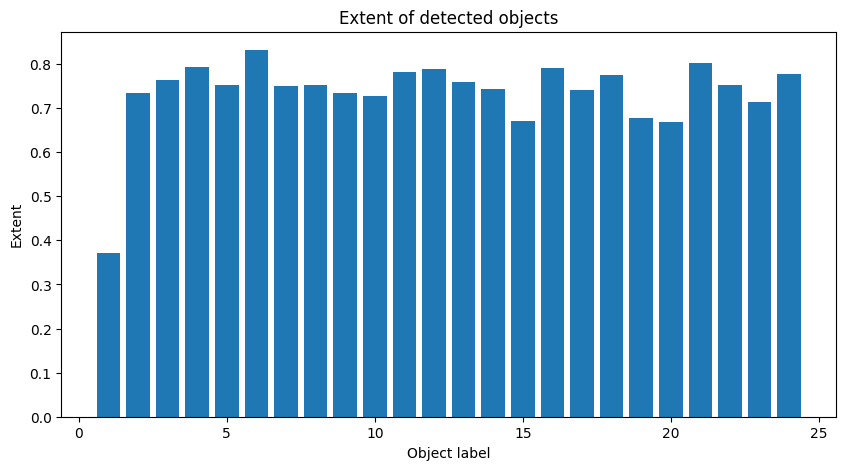

In [65]:
plt.figure(figsize=(10, 5))
plt.bar(df["label"], df["extent"])
plt.xlabel("Object label")
plt.ylabel("Extent")
plt.title("Extent of detected objects")
plt.show()

In [66]:
print("""
In this exercise, objects were segmented from the image using Otsu thresholding.
After segmentation, connected components were labeled.

For each object, the following region properties were extracted:

label: unique number assigned to each object
area: number of pixels inside the object
eccentricity: shows how elongated the object is
extent: ratio between object area and bounding box area
axis_major_length: length of the major axis of the fitted ellipse

The properties were stored in a pandas DataFrame for easier analysis.
""")


In this exercise, objects were segmented from the image using Otsu thresholding.
After segmentation, connected components were labeled.

For each object, the following region properties were extracted:

label: unique number assigned to each object
area: number of pixels inside the object
eccentricity: shows how elongated the object is
extent: ratio between object area and bounding box area
axis_major_length: length of the major axis of the fitted ellipse

The properties were stored in a pandas DataFrame for easier analysis.

